/tmp/ipykernel_84701/3964077392.py:215: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax_entropy.set_xlim(0, max_duration)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Logo file not found, creating a placeholder.
--- Generating Static Comparison Plot ---
Static plot saved to ../plots/multimode_comparison.png

--- Generating Multi-Mode Animation GIF ---
No data loaded, cannot generate GIF.

Displaying final static plot...


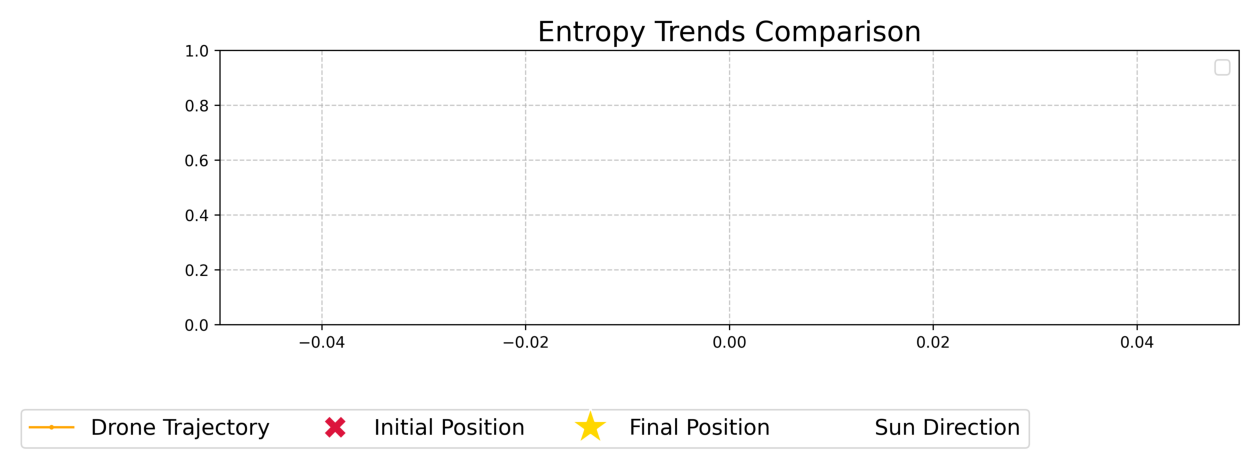

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, to_rgba
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MultipleLocator
import seaborn as sns
import matplotlib.patches as mpatches
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.ticker import MultipleLocator
import matplotlib.image as mpimg
from matplotlib.collections import LineCollection
# New imports for the custom legend handler and GIF generation
import matplotlib.patches as mpatches
from matplotlib.legend_handler import HandlerBase
import imageio
import io

# --- Setup: Logo, Palettes, and Helper Functions ---
try:
    # This path needs to be correct for the logo to appear.
    logo_arr = mpimg.imread("/home/pantheon/drea/neural_mpc/ros/src/nmpc_ros/plot_tools/sun_orientation.png")
except FileNotFoundError:
    print("Logo file not found, creating a placeholder.")
    logo_arr = np.zeros((10, 10, 4)) # Create a transparent placeholder if logo is missing

paired_palette = sns.color_palette("Paired")
dark_paired_palette = sns.color_palette("dark")

def get_latest_csv(mode, directory, suffix="plot_data.csv"):
    pattern = os.path.join(directory, f"{mode}*{suffix}")
    files = glob.glob(pattern)
    return max(files, key=os.path.getmtime) if files else None

class HandlerGradient(HandlerBase):
    def __init__(self, cmap, num_stripes=64, **kw):
        super().__init__(**kw)
        self.cmap = cmap
        self.num_stripes = num_stripes

    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        gradient = np.linspace(0, 1, self.num_stripes)
        colors = self.cmap(gradient)
        stripes = []
        for i in range(self.num_stripes):
            stripe = mpatches.Rectangle([xdescent + i * width / self.num_stripes, ydescent],
                                     width / self.num_stripes, height,
                                     fc=colors[i], transform=trans, edgecolor='none')
            stripes.append(stripe)
        return stripes

class HandlerImage(HandlerBase):
    def __init__(self, image_arr, zoom=1.0, **kw):
        super().__init__(**kw)
        self.image_arr = image_arr
        self.zoom = zoom

    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        imagebox = OffsetImage(self.image_arr, zoom=self.zoom)
        ab = AnnotationBbox(imagebox, (xdescent + 0.5 * width, ydescent + 0.5 * height),
                            frameon=False, xycoords=trans, box_alignment=(0.5, 0.5), pad=0)
        return [ab]

def load_csv_data(csv_path):
    with open(csv_path, 'r') as f:
        first_line = f.readline().strip()
    parts = first_line.split(',')
    if parts[0] == "tree_positions":
        tree_positions_list = [float(x) for x in parts[1:] if x]
        tree_positions = np.array(tree_positions_list).reshape(len(tree_positions_list) // 2, 2) if tree_positions_list else np.array([]).reshape(0,2)
    else:
        tree_positions = None
    df = pd.read_csv(csv_path, skiprows=2)
    return (
        df["time"].values,
        df["x"].values,
        df["y"].values,
        df["theta"].values,
        df["entropy"].values,
        df[[col for col in df.columns if col.startswith("lambda_")]].values,
        tree_positions
    )

def plot_trajectory_subplot(ax, x, y, theta, trees, lambda_history, custom_cmap,
                            tick_label_fontsize, subplot_title_fontsize, mode_label_for_title):
    ax.plot(x, y, marker='o', color='orange', linewidth=1.0, markersize=1.0, label="Drone Trajectory")
    ax.scatter(x[0], y[0], color='crimson', s=150, marker='X', label="Initial Position", zorder=4)
    ax.scatter(x[-1], y[-1], color='gold', s=150, marker='*', label="Final Position", zorder=4)

    if trees is not None and trees.size > 0:
        for i in range(trees.shape[0]):
            final_lambda = lambda_history[-1, i] if lambda_history.shape[1] > i else 0.5
            tree_color = custom_cmap(final_lambda)
            ax.scatter(trees[i, 0], trees[i, 1], color=tree_color, s=100, marker='o', zorder=3)

    step = max(1, len(x) // 100)
    for idx_arr in range(0, len(x), step):
        x0, y0, t = x[idx_arr], y[idx_arr], theta[idx_arr]
        x1 = x0 + 1.5 * np.cos(t)
        y1 = y0 + 1.5 * np.sin(t)
        ax.annotate("", xy=(x1, y1), xytext=(x0, y0), arrowprops=dict(arrowstyle="->", color="orange", linewidth=1.5))

    ax.tick_params(axis='both', labelsize=tick_label_fontsize)
    ax.set_aspect('equal', adjustable='box')
    ax_t.set_xlim(-4.0, 18.5)
    ax_t.set_ylim(-20.5, 1.5)
    ax.set_title(mode_label_for_title, fontsize=subplot_title_fontsize)
    ax.xaxis.set_major_locator(MultipleLocator(5))
    ax.yaxis.set_major_locator(MultipleLocator(5))

def plot_entropy_subplot(ax, time_history, entropy, label, color, axis_label_fontsize, tick_label_fontsize):
    ax.plot(time_history, entropy, linewidth=1.5, markersize=1.0, label=label, color=color)
    ax.set_xlabel("Time (s)", fontsize=axis_label_fontsize)
    ax.set_ylabel("Entropy", fontsize=axis_label_fontsize)
    ax.tick_params(axis='both', labelsize=tick_label_fontsize)

# --- Main Configuration ---
modes = ["linear", "greedy", "mower_gnek", "mower_normal", "mpc"]
baselines_dir = "../plots"

# Font sizes
axis_label_fontsize = 15
tick_label_fontsize = 14
subplot_title_fontsize = 18
legend_fontsize = 14
suptitle_fontsize = 22

# Colormap and labels
custom_cmap = LinearSegmentedColormap.from_list(
    "custom_cmap", [paired_palette[3], (0.5, 0.5, 0.5), dark_paired_palette[1]]
)
algorithm_labels = {
    "linear": "Linear Path",
    "greedy": "Greedy Approach",
    "mower_gnek": "Mower - Good slow",
    "mower_normal": "Mower - Poor normal",
    "mpc": "Neural IPP MPC",
}
colors = sns.color_palette("tab10", len(modes))
mode_colors = {mode: colors[i] for i, mode in enumerate(modes)}

# --- 1. Generate Static Multi-mode Comparison Plot ---
print("--- Generating Static Comparison Plot ---")
fig = plt.figure(figsize=(16, 7.5))
gs = GridSpec(2, 4, figure=fig, width_ratios=[1,1,1,1], height_ratios=[1,1], wspace=0.25, hspace=0.35)

any_trees = False
data_cache = {}

# Load data and plot trajectory subplots
for i, mode in enumerate(modes):
    csv_file = get_latest_csv(mode, baselines_dir)
    if not csv_file:
        print(f"Warning: No CSV found for mode '{mode}'. Skipping.")
        continue
    try:
        time_h, x, y, theta, entropy, lambda_h, trees = load_csv_data(csv_file)
        data_cache[mode] = {'time': time_h, 'x': x, 'y': y, 'theta': theta, 'entropy': entropy, 'lambda_h': lambda_h, 'trees': trees}
        if trees is not None and trees.size > 0:
            any_trees = True
    except Exception as e:
        print(f"Error loading or processing {csv_file}: {e}")
        continue

    if i < 4: ax_t = fig.add_subplot(gs[0, i])
    else: ax_t = fig.add_subplot(gs[1, 0])

    label = algorithm_labels.get(mode, mode.capitalize())
    plot_trajectory_subplot(ax_t, x, y, theta, trees, lambda_h, custom_cmap,
                            tick_label_fontsize, subplot_title_fontsize, label)
    oim = OffsetImage(logo_arr, zoom=0.045)
    ab = AnnotationBbox(oim, (-0.01, 0.99), xycoords="axes fraction", frameon=False)
    ax_t.add_artist(ab)

# Entropy subplot spanning three columns
ax_entropy = fig.add_subplot(gs[1, 1:4])
for i, mode in enumerate(modes):
    if mode not in data_cache: continue
    data = data_cache[mode]
    label = algorithm_labels.get(mode, mode.capitalize())
    plot_entropy_subplot(ax_entropy, data['time'], data['entropy'], label, mode_colors[mode],
                         axis_label_fontsize, tick_label_fontsize)
    ax_entropy.axvline(x=data['time'][-1], color=mode_colors[mode], linestyle='--', linewidth=1.5)

# Finalize legends and layout for static plot
legend_handles = [
    Line2D([0], [0], color='orange', lw=1.5, marker='o', markersize=2, label='Drone Trajectory'),
    Line2D([0], [0], marker='X', color='w', markerfacecolor='crimson', markersize=15, label='Initial Position'),
    Line2D([0], [0], marker='*', color='w', markerfacecolor='gold', markersize=25, label='Final Position')
]
legend_labels = ['Drone Trajectory', 'Initial Position', 'Final Position']
image_handle = mpatches.Patch(color='none')
legend_handles.append(image_handle)
legend_labels.append('Sun Direction')
handler_map = {image_handle: HandlerImage(logo_arr, zoom=0.04)}
if any_trees:
    grad_handle = mpatches.Patch(color='none')
    legend_handles.append(grad_handle)
    legend_labels.append('Raw(Green)-Ripe(Red) Belief')
    handler_map[grad_handle] = HandlerGradient(cmap=custom_cmap)

if 'linear' in data_cache:
    max_duration = data_cache['linear']['time'][-1]
    print(f"Animation duration set by MPC execution time: {max_duration:.2f}s")
else:
    print("Warning: 'mpc' data not found. Using max duration of all available modes as fallback.")
    max_duration = max(data['time'][-1] for data in data_cache.values()) if data_cache else 0

#fig.suptitle("Algorithm Trajectories & Entropy Comparison", fontsize=suptitle_fontsize)
fig.legend(handles=legend_handles, labels=legend_labels, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=5, fontsize=legend_fontsize, handler_map=handler_map)
ax_entropy.set_title("Entropy Trends Comparison", fontsize=subplot_title_fontsize)
ax_entropy.set_xlim(0, max_duration)
ax_entropy.legend(loc='upper right', bbox_to_anchor=(1.0, 1.0), fontsize=tick_label_fontsize-2)
ax_entropy.grid(True, linestyle='--', alpha=0.7)

output_path_static = os.path.join(baselines_dir, "multimode_comparison.png")
fig.savefig(output_path_static, dpi=350, bbox_inches='tight')
print(f"Static plot saved to {output_path_static}")
plt.close(fig) # Close figure to free memory

# --- 2. Generate GIF Animation for Multi-Mode Comparison ---
print("\n--- Generating Multi-Mode Animation GIF ---")
if not data_cache:
    print("No data loaded, cannot generate GIF.")
else:
    # Animation parameters
    FPS = 15
    FADE_LENGTH = 50 # Number of recent points to have stronger alpha
    output_gif_path = os.path.join(baselines_dir, "multimode_animation.gif")
    
    ## MODIFICA: Imposta la durata dell'animazione basandosi SOLO sul tempo di esecuzione dell'MPC.
    # Se i dati 'mpc' non sono disponibili, usa la durata massima tra gli altri algoritmi come fallback.
    if 'mpc' in data_cache:
        max_duration = data_cache['mpc']['time'][-1]
        print(f"Animation duration set by MPC execution time: {max_duration:.2f}s")
    else:
        print("Warning: 'mpc' data not found. Using max duration of all available modes as fallback.")
        max_duration = max(data['time'][-1] for data in data_cache.values()) if data_cache else 0
    
    ## MODIFICA: Campiona i fotogrammi (1 su 4) per accelerare la generazione della GIF.
    # L'intervallo di tempo tra i fotogrammi viene aumentato da 1.0/FPS a 4.0/FPS.
    time_step = 10.0 / FPS 
    animation_times = np.arange(0, max_duration, time_step)
    print(f"Generating animation with 1 frame every 4 steps (time step: {time_step:.3f}s) to speed up processing.")
    
    # Setup figure for animation
    fig_gif = plt.figure(figsize=(16, 7.5))
    gs_gif = GridSpec(2, 4, figure=fig_gif, width_ratios=[1,1,1,1], height_ratios=[1,1], wspace=0.25, hspace=0.35)
    #fig_gif.suptitle("Comparing Algorithm Evolution", fontsize=suptitle_fontsize, y=0.98)

    axs_traj_gif = {}
    for i, mode in enumerate(modes):
        if mode not in data_cache: continue
        if i < 4: axs_traj_gif[mode] = fig_gif.add_subplot(gs_gif[0, i])
        else: axs_traj_gif[mode] = fig_gif.add_subplot(gs_gif[1, 0])
    ax_entropy_gif = fig_gif.add_subplot(gs_gif[1, 1:4])
    
    frames = []

    # Main animation loop
    for t_current in animation_times:
        # Clear all axes for the new frame
        ax_entropy_gif.cla()
        for ax in axs_traj_gif.values():
            ax.cla()

        # Update each mode's plots
        for i, mode in enumerate(modes):
            if mode not in data_cache: continue
            data = data_cache[mode]
            ax_t = axs_traj_gif[mode]
            
            # Find the closest data index for the current animation time
            k = np.searchsorted(data['time'], t_current)
            # This logic correctly handles algorithms that finish early.
            # 'k' will be capped at the last available index, freezing the plot.
            if k >= len(data['time']):
                 k = len(data['time']) - 1

            # --- Plot Trajectory Subplot ---
            ax_t.set_aspect('equal', adjustable='box')
            ax_t.set_xlim(-4.0, 18.5)
            ax_t.set_ylim(-20.5, 1.5)
            ax_t.set_title(f"{algorithm_labels[mode]}\nTime: {t_current:.1f}s", fontsize=subplot_title_fontsize-2)
            ax_t.xaxis.set_major_locator(MultipleLocator(5))
            ax_t.yaxis.set_major_locator(MultipleLocator(5))
            ax_t.tick_params(axis='both', labelsize=tick_label_fontsize-2)
            
            if data['trees'] is not None and data['trees'].size > 0:
                for tree_idx in range(data['trees'].shape[0]):
                    current_lambda = data['lambda_h'][k, tree_idx] if data['lambda_h'].shape[1] > tree_idx else 0.5
                    ax_t.scatter(data['trees'][tree_idx, 0], data['trees'][tree_idx, 1], color=custom_cmap(current_lambda), s=100, marker='o', zorder=3)

            ax_t.scatter(data['x'][0], data['y'][0], color='crimson', s=150, marker='X', zorder=4)
            
            # Fading trajectory
            points = np.array([data['x'][:k+1], data['y'][:k+1]]).T.reshape(-1, 1, 2)
            segments = np.concatenate([points[:-1], points[1:]], axis=1)
            num_segments = len(segments)
            base_color = to_rgba('orange')
            segment_colors = np.tile(base_color, (num_segments, 1))
            fade_start_idx = max(0, num_segments - FADE_LENGTH)
            alphas = np.linspace(0.2, 1.0, num_segments - fade_start_idx)
            if (num_segments - fade_start_idx) > 0: # Avoid error if empty
                segment_colors[fade_start_idx:, 3] = alphas
            if num_segments > FADE_LENGTH: segment_colors[:fade_start_idx, 3] = 0.2
            
            if num_segments > 0: # Avoid error if no segments
                lc = LineCollection(segments, colors=segment_colors, linewidths=1.5)
                ax_t.add_collection(lc)

            # Current drone position
            if k < len(data['x']): # Ensure index is valid
                ax_t.scatter(data['x'][k], data['y'][k], color='darkorange', s=100, zorder=5)
            
            # --- Plot Entropy Subplot ---
            ax_entropy_gif.plot(data['time'][:k+1], data['entropy'][:k+1], color=mode_colors[mode], linewidth=2, label=algorithm_labels[mode])
            if k < len(data['time']): # Ensure index is valid
                ax_entropy_gif.scatter(data['time'][k], data['entropy'][k], color=mode_colors[mode], s=50, zorder=5)
        
        # Finalize entropy plot for this frame
        ax_entropy_gif.set_title("Entropy Trends Comparison", fontsize=subplot_title_fontsize)
        ax_entropy_gif.set_xlabel("Time (s)", fontsize=axis_label_fontsize)
        ax_entropy_gif.set_ylabel("Entropy", fontsize=axis_label_fontsize)
        ax_entropy_gif.set_xlim(0, max_duration)
        ax_entropy_gif.legend(loc='upper right', fontsize=tick_label_fontsize-2)
        ax_entropy_gif.grid(True, linestyle='--', alpha=0.7)
        
        # Save frame to buffer
        buf = io.BytesIO()
        fig_gif.savefig(buf, format='png', dpi=120)
        buf.seek(0)
        frames.append(imageio.imread(buf))
        buf.close()

    # Save the final GIF
    plt.close(fig_gif)
    imageio.mimsave(output_gif_path, frames, fps=FPS)
    print(f"Successfully generated and saved GIF to {output_gif_path}")

# --- 3. Display Static Plot ---
# This re-opens the saved static image for display in notebooks.
print("\nDisplaying final static plot...")
try:
    display_img = plt.imread(output_path_static)
    fig_display, ax_display = plt.subplots(figsize=(16, 8.5))
    ax_display.imshow(display_img)
    ax_display.axis('off')
    plt.show()
except (NameError, FileNotFoundError):
    print("Could not display static plot as it was not generated or found.")